# Ranking de Keywords por Periodo

Agrupa todas as palavras-chave mencionadas em artigos dentro de um periodo e ordena por quantidade de mencoes.

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from neo4j import GraphDatabase
from dotenv import load_dotenv

load_dotenv('.env')

NEO4J_URI = os.getenv('NEO4J_URI', 'bolt://localhost:7687')
NEO4J_USER = os.getenv('NEO4J_USER', 'neo4j')
NEO4J_PASSWORD = os.getenv('NEO4J_PASSWORD')

if not NEO4J_PASSWORD:
    raise ValueError('Defina NEO4J_PASSWORD no arquivo .env antes de executar.')

In [8]:
# Parametros de consulta
DATA_INICIO = '2020-04-20'
DATA_FIM    = '2026-04-30'
TOP_N       = 20   # quantas keywords exibir no grafico

In [5]:
def buscar_ranking_keywords(data_inicio, data_fim):
    query = '''
    MATCH (a:Article)-[:MENCIONA]->(k:Keyword)
    WHERE date(a.publishedAt) >= date($data_inicio)
      AND date(a.publishedAt) <= date($data_fim)
    RETURN k.word AS keyword, count(*) AS mencoes
    ORDER BY mencoes DESC
    '''

    with GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD)) as driver:
        with driver.session() as session:
            result = session.run(query, data_inicio=data_inicio, data_fim=data_fim)
            registros = [dict(r) for r in result]

    return pd.DataFrame(registros)

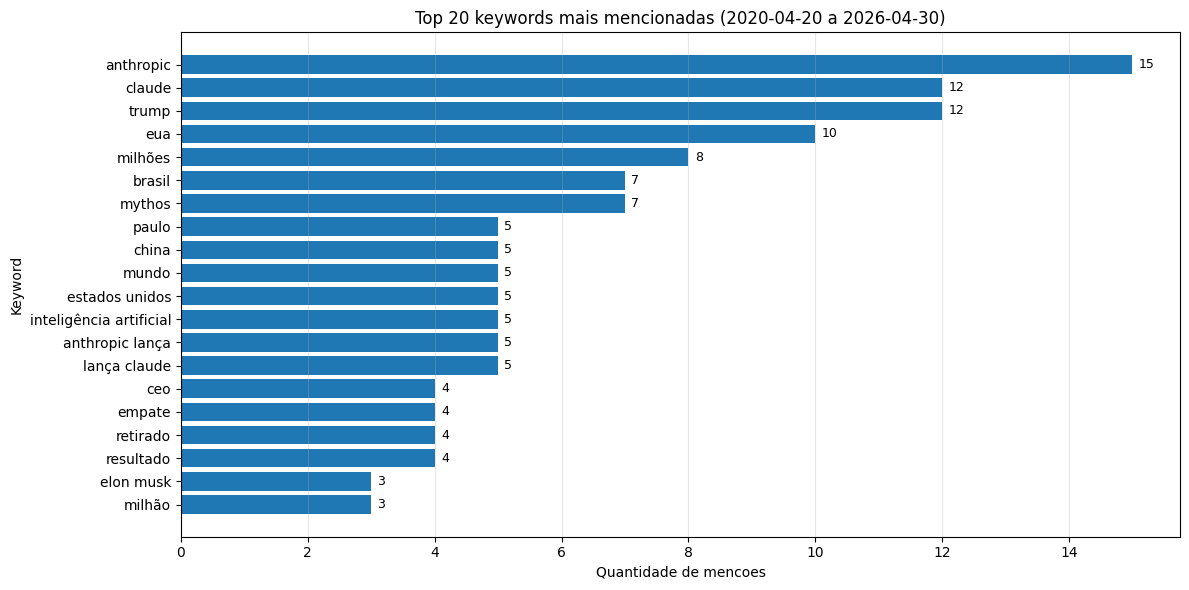

In [11]:
df = buscar_ranking_keywords(DATA_INICIO, DATA_FIM)

if df.empty:
    print('Nenhuma keyword encontrada no periodo informado.')
else:
    top = df.head(TOP_N)

    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(top['keyword'][::-1], top['mencoes'][::-1])

    # Rotulo com valor em cada barra
    for bar, val in zip(bars, top['mencoes'][::-1]):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                str(val), va='center', fontsize=9)

    ax.set_title(f'Top {TOP_N} keywords mais mencionadas ({DATA_INICIO} a {DATA_FIM})')
    ax.set_xlabel('Quantidade de mencoes')
    ax.set_ylabel('Keyword')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    df